<h1>Checking the data</h1>

In [2]:
import pandas as pd
df = pd.read_csv('data/employee_attrition_dataset.csv')
df.shape
df.info()
df.isnull().sum()
df['Attrition'].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

Attrition
No     0.811
Yes    0.189
Name: proportion, dtype: float64

<h1>Explore the relationships</h1>

<Axes: xlabel='Overtime'>

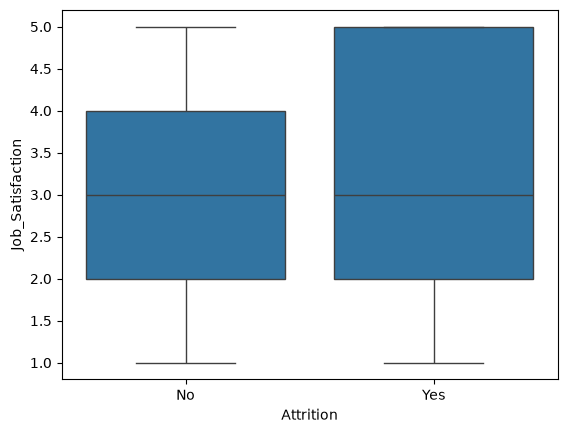

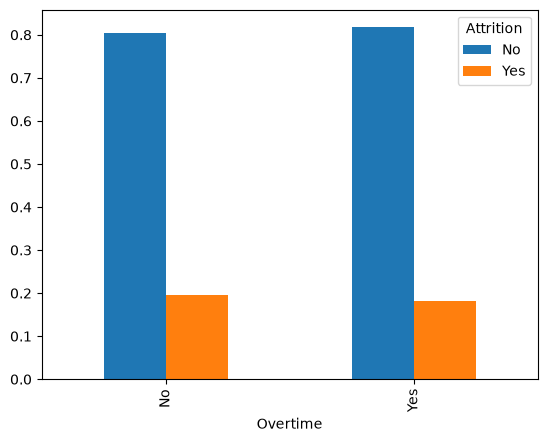

In [3]:
import seaborn as sns

sns.boxplot(x='Attrition',y='Job_Satisfaction',data=df)

pd.crosstab(df['Overtime'],df['Attrition'],normalize='index').plot(kind='bar')

<h2>Relationship notes</h2>

Gender and marrital status excluding for moral reasons<br>
<b>HR and IT have the most attrition</b><br>
Analyst has the least attrition - others are same level<br>
Job level 1 also has least attrition<br>Lower monthly incomes have slightly less attrition but large error bars<br>No overtime has more attrition<br><b>Attrition comes with more years in the company</b><br> Relationship with manager at higher ratings leads to lower attrition

<h1>Prepping the data for the training model</h1>
Need to translate the string(True/false) data into integers

In [4]:
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df,drop_first=True)
X = df_encoded.drop('Attrition_Yes',axis=1)
y = df_encoded['Attrition_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       False       0.78      0.56      0.65       162
        True       0.14      0.32      0.20        38

    accuracy                           0.52       200
   macro avg       0.46      0.44      0.43       200
weighted avg       0.66      0.52      0.57       200



<Axes: >

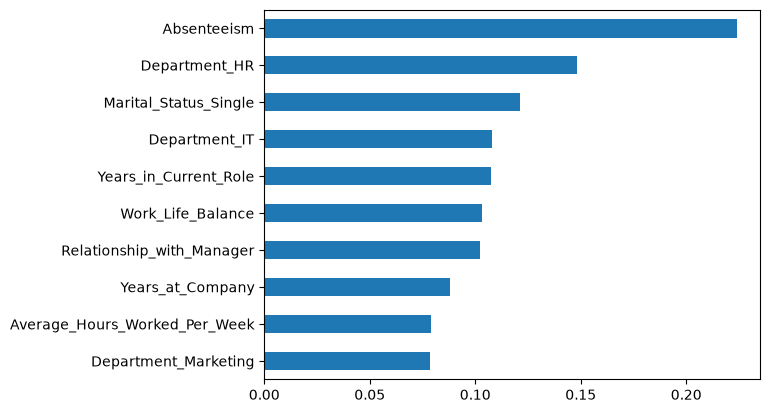

In [6]:
importances = pd.Series(model.coef_[0], index=X.columns).sort_values()
importances.tail(10).plot(kind='barh')

Quick hypothesis test

<Axes: xlabel='Attrition', ylabel='Years_in_Current_Role'>

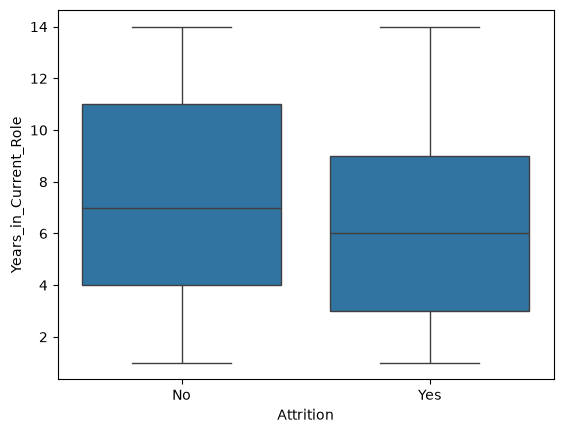

In [7]:
it_df = df[df['Department'] == 'IT']
sns.boxplot(x='Attrition',y='Years_in_Current_Role',data=it_df)

<h1>Risk predictor for each person</h1>

In [12]:
risk_scores = model.predict_proba(X_test_scaled)[:,1]
x_scaled = scaler.transform(X)
risk_scores = model.predict_proba(x_scaled)[:, 1]
df['Attrition_risk'] = risk_scores
df[['Employee_ID', 'Attrition_risk']].sort_values('Attrition_risk', ascending=False).head(10)

,Employee_ID,Attrition_risk
592,593,0.833592
406,407,0.808213
347,348,0.806971
856,857,0.777731
99,100,0.776947
178,179,0.770433
869,870,0.764560
671,672,0.763787
467,468,0.762195
190,191,0.760794
